In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import src.funct_simulation as f
import pandas as pd
import random
from threading import Thread
from time import time

In [158]:
import scipy.stats as stats

In [159]:
import scipy
import matplotlib

# Easy model
## generate data

In [106]:
def log_gauss_ratio(x,mu1,mu2,sigma1,sigma2): #ratio f(1)/f(2)
    return np.log(sigma2/sigma1)-1/(2*sigma1**2)*(x-mu1)**2+0.5/sigma2**2*(x-mu2)**2

In [107]:
gauss_ratio(10,0,0.2,1,1)

0.1380692373108942

In [122]:
def max_tg(mu_x, mu_y, sigma_x, sigma_y ):
    p = stats.truncnorm(loc =mu_x, scale = sigma_x, a= -mu_x/sigma_x, b = np.infty)
    q = stats.truncnorm(loc =mu_y, scale = sigma_y, a= -mu_y/sigma_y, b = np.infty)
    x = p.rvs()
    #x = np.random.normal(mu_x,sigma_x)
    w = np.random.rand()*p.pdf(x)
    #f.normal_dens_1d(mu_x,sigma_x,x)
    
    if w < q.pdf(x):
    #f.normal_dens_1d(mu_y,sigma_y,x):
        return x,x
    else:
        while True:
            y = q.rvs()
            #np.random.normal(mu_y, sigma_y)
            w = np.random.rand()*q.pdf(y)
            if w > p.pdf(y): #f.normal_dens_1d(mu_x,sigma_x,y):
                return x,y


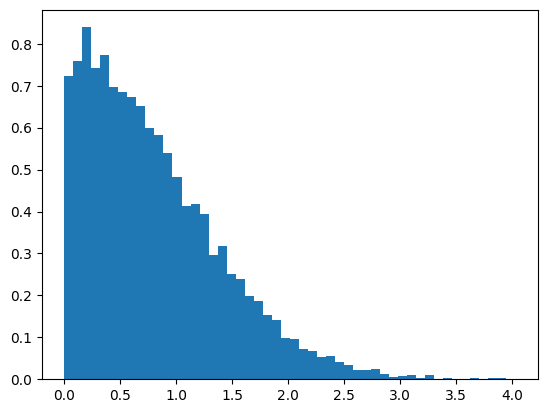

In [125]:
r1 = []
r2 = []
for i in range(0,10000):
    x,y = max_tg(0,6,1,1)
    r1.append(x)
    r2.append(y)
plt.hist(r1, bins = 50, density=True);

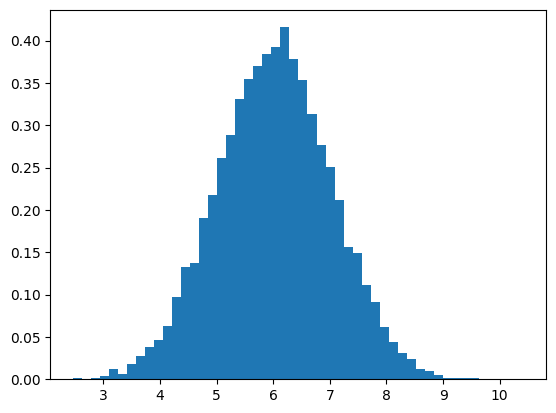

In [126]:
plt.hist(r2, bins = 50, density=True);

In [3]:
def countmemb(itr,I):
    # in this way itr might have different dimensions for different factor, no good
    count = np.zeros((itr.shape[1],I))
    for d in range(itr.shape[1]):
        for val in itr[:,d]:
            count[d,val] += 1
    return count

In [4]:
class Data:
    def __init__(self):
        self.I = 0
        self.J = 0
        self.N = 0
        self.rho = 0
        #self.mu = [0,0]
        self.tau_0 = 1
        #self.tau_1 = 1
        #self.tau_2 = 1
        self.u = None
        self.v = None
        self.ii = None
        self.iss = None
        self.mean_y = None
        self.mean_y_s = None
        self.N_s = None
    
    def generate(self, N,I,J, tau_0,rho):
        self.J = J
        self.I = I
        self.N = N
        self.rho = rho
        self.tau_0 = tau_0
        # supposing uniform assignment of individuals to factor/levels   
        self.ii = np.random.randint(0,self.I, size=(self.N,2)) # this should go from 0 to I-1
        self.u = np.random.normal(0,1,size=I)  
        self.v = np.random.normal(0,1, size=J)  
        # aux = np.sum(self.a[self.ii,np.arange(self.K)], axis = 1)
        aux = np.array([self.rho*self.u[self.ii[n,0]]*self.v[self.ii[n,0]]  for n in range(N)])
        self.y = aux+np.random.normal(0,1/np.sqrt(tau_0), size = self.N) 
        self.mean_y = np.mean(self.y)
        self.N_s = countmemb(self.ii,self.I)
        #self.N_sl = [[ np.zeros((self.iss[i],self.iss[j])) for j in range(self.K)] for i in range(self.K)]
        #for i in range(self.K) :
        #    for j in range(self.K):
        #        for n in range(self.N):
        #            self.N_sl[i][j][self.ii[n,i], self.ii[n,j]] += 1
        
    def asymptotic_regimes(self,num,I=10, tau_0=1, rho= 1):
        x =self
        self.rho = rho
        if num ==1:
            # dense regime
            p = 0.3
        elif num == 2:
            # sparse 
            p = 10/(I**0.5)
        else:
            p = 10/I

        N = np.random.binomial(I**2, p ,1)[0]
        ii = np.zeros((N,2)).astype(int)
        u = np.random.normal(0,1,size=I)  
        v = np.random.normal(0,1,size=I)  

        y= np.zeros(N)
        xx = random.sample(range(I**2),N) 
        for i in range(N):
            ac = xx[i]//I
            b = xx[i]-ac*I
            ii[i,0] = ac
            ii[i,1] = b
        ii= np.array(pd.DataFrame(ii).apply(convert_col, axis = 0)).astype('int')
        I = ii.max()+1

        aux = np.array([self.rho*u[ii[n,0]]*v[ii[n,1]]  for n in range(N)])
        y = aux+np.random.normal(0,np.sqrt(1/tau_0), size = N)
        x.N = N
        x.I = I
        x.J = I 
        x.tau_0 = tau_0
        x.u = u
        x.v = v
        x.y = y
        x.ii = ii
        x.N_s = countmemb(ii,I)


  
def convert_col(x):
    return x.replace({i:e for e,i in enumerate(set(x))})

## estimate it

In [5]:
def catalytic_gamma_max(a,b_x,b_y):
    X= np.random.gamma(shape = a, scale = b_x)
    Y = np.random.gamma(shape = a, scale = b_y)
    if np.log(np.random.rand()) < (+1/b_x-1/b_y)*(X-Y):
        Y = X +0

    return (X,Y)

In [137]:


class iter_value:    
    def __init__(self, data,T):
        self.tau_0 = 1
        self.u = np.ones(data.I)
        self.v = np.ones(data.J)
        self.rho = 1
        
        #self.u_aux = np.array([[data.y[data.ii[:,0] == i]@self.v[data.ii[:,1][data.ii[:,0] == i]], np.sum(self.v[data.ii[:,1][data.ii[:,0] == i]]**2)]  for i in range(data.I)])
        #self.v_aux = np.array([[data.y[data.ii[:,1] == j]@self.u[data.ii[:,0][data.ii[:,1] == j]], np.sum(self.u[data.ii[:,0][data.ii[:,1] == j]]**2)]  for j in range(data.J)])
        self.SS0 = 0
        self.SS0_chain = np.zeros(T+1)
        self.rho_chain = np.zeros(T+1)
        self.rho_chain[0] = self.rho + 0
        #self.a_means_chains= np.zeros((data.K,T+1 ))
        self.tau_chain = np.zeros(T+1)
        self.tau_chain[0] = self.tau_0
        self.umean_chain = np.zeros((T+1))
        self.umean_chain[0] = np.mean(self.u)
        self.vmean_chain = np.zeros((T+1))
        self.vmean_chain[0] = np.mean(self.v)
        self.unorm_chain = np.zeros((T+1))
        self.unorm_chain[0] = self.u@self.u
        self.vnorm_chain = np.zeros((T+1))
        self.vnorm_chain[0] = self.v@self.v
        

    def update(self,data, t):
        # update tau_1 and U 
        self.u_aux = np.array([[data.y[data.ii[:,0] == i]@self.v[data.ii[:,1][data.ii[:,0] == i]], np.sum(self.v[data.ii[:,1][data.ii[:,0] == i]]**2)]  for i in range(data.I)])
        self.u= np.random.multivariate_normal( (self.rho*self.tau_0*self.u_aux[:,0])/(self.tau_0*self.rho**2*self.u_aux[:,1]+1), np.diag(1/(self.tau_0*self.rho**2*self.u_aux[:,1]+1)))
        
        # update tau_2 and V 
        self.v_aux = np.array([[data.y[data.ii[:,1] == j]@self.u[data.ii[:,0][data.ii[:,1] == j]], np.sum(self.u[data.ii[:,0][data.ii[:,1] == j]]**2)]  for j in range(data.J)])
        self.v= np.random.multivariate_normal( (self.rho*self.tau_0*self.v_aux[:,0])/(self.tau_0*self.rho**2*self.v_aux[:,1]+1), np.diag(1/(self.tau_0*self.rho**2*self.v_aux[:,1]+1)))
        
        #self.tau_1 = np.random.gamma( shape= (data.J+data.I+1)/2 ,scale=2/(sum((self.u-self.mu[0])**2)+ sum((self.v-self.mu[1])**2)))
        
        self.SS0 = sum( (data.y - self.rho* self.u[data.ii[:,0]]* self.v[data.ii[:,1]])**2)
        self.tau_0 = np.random.gamma(shape= data.N/2 + 0.5,scale=2/self.SS0)
        
        # do metropolis step for this [bad]
        #rho_p = np.random.normal(self.rho, 1)
        
        # gaussian improper
        prec = np.sum(self.u[data.ii[:,0]]**2*self.v[data.ii[:,1]]**2)
        mu = np.sum(data.y*self.u[data.ii[:,0]] * self.v[data.ii[:,1]]) / prec
        self.rho = stats.truncnorm(loc =mu , scale = 1/(self.tau_0*np.sqrt(prec)), a = -mu*(self.tau_0*np.sqrt(prec)), b= np.infty).rvs()
        #np.random.normal( , )
        
        # metropolis 
        #rho_p = self.rho + np.random.normal(0, 1/np.sqrt(2))
        #prec = np.sum(self.u[data.ii[:,0]]**2 * self.v[data.ii[:,1]]**2)
        #acc = False
        #if rho_p > 0:
        #    if np.log(np.random.rand()) < -0.5*np.log(rho_p/self.rho)-self.tau_0/2*( (rho_p**2-self.rho**2)*prec-2*(rho_p-self.rho)*np.sum(data.y*self.u[data.ii[:,0]]*self.v[data.ii[:,1]])):
        #        acc = True
        ##        print("yess")
        #        self.rho = rho_p
        self.rho_chain[t] = self.rho
        self.tau_chain[t] = self.tau_0
        self.umean_chain[t] = np.mean(self.u)
        self.vmean_chain[t] = np.mean(self.v)
        self.unorm_chain[t] = self.u@self.u
        self.vnorm_chain[t] = self.v@self.v
        self.SS0_chain[t] = self.SS0
        
    def coupled_update(self,iter2,data, t, close):
        # update tau_1 and U 
        self.u_aux = np.array([[data.y[data.ii[:,0] == i]@self.v[data.ii[:,1][data.ii[:,0] == i]], np.sum(self.v[data.ii[:,1][data.ii[:,0] == i]]**2)]  for i in range(data.I)])
        iter2.u_aux = np.array([[data.y[data.ii[:,0] == i]@iter2.v[data.ii[:,1][data.ii[:,0] == i]], np.sum(iter2.v[data.ii[:,1][data.ii[:,0] == i]]**2)]  for i in range(data.I)])

        #np.diag(self.tau_0*self.rho**2*self.u_aux[:,1]+1)
        prec1 = self.tau_0*self.u_aux[:,1]*self.rho**2 +1
        prec2 = iter2.tau_0*iter2.rho**2*iter2.u_aux[:,1]+1
        if close:
            if np.all( prec1 == prec2 ):
                self.u, iter2.u= f.reflection_coupling((self.rho*self.tau_0*self.u_aux[:,0])/prec1, (iter2.rho*iter2.tau_0*iter2.u_aux[:,0])/prec2, np.diag(1/prec1))
            else:
                self.u, iter2.u = f.maximal_coupling_normal_d( (self.rho*self.tau_0*self.u_aux[:,0])/prec1, (iter2.rho*iter2.tau_0*iter2.u_aux[:,0])/prec2, np.diag(1/prec1),np.diag(1/prec2), diag=True )
        else:
            Z = np.random.normal(0,1,(data.I))
            self.u = (self.tau_0*self.u_aux[:,0])/prec1 + Z/np.sqrt(prec1)
            iter2.u = (iter2.tau_0*iter2.u_aux[:,0])/prec2 + Z/np.sqrt(prec2)
        
        # update tau_2 and V 
        self.v_aux = np.array([[data.y[data.ii[:,1] == j]@self.u[data.ii[:,0][data.ii[:,1] == j]], np.sum(self.u[data.ii[:,0][data.ii[:,1] == j]]**2)]  for j in range(data.J)])
        iter2.v_aux = np.array([[data.y[data.ii[:,1] == j]@iter2.u[data.ii[:,0][data.ii[:,1] == j]], np.sum(iter2.u[data.ii[:,0][data.ii[:,1] == j]]**2)]  for j in range(data.J)])
        
        prec1 = self.tau_0*self.v_aux[:,1]*self.rho**2+1
        prec2 = iter2.tau_0*iter2.v_aux[:,1]*iter2.rho**2+1
        if close:
            if np.all( prec1 == prec2 ):
                self.v, iter2.v = f.reflection_coupling((self.rho*self.tau_0*self.v_aux[:,0])/prec1, (iter2.rho*iter2.tau_0*iter2.v_aux[:,0])/prec2, np.diag(1/prec1))
            else:
                self.v, iter2.v = f.maximal_coupling_normal_d( (self.rho*self.tau_0*self.v_aux[:,0])/prec1, (iter2.rho*iter2.tau_0*iter2.v_aux[:,0])/prec2, np.diag(1/prec1),np.diag(1/prec2), diag=True )
        else:
            Z = np.random.normal(0,1,(data.J))
            self.v = (self.tau_0*self.v_aux[:,0])/prec1 + Z/np.sqrt(prec1)
            iter2.v = (iter2.tau_0*iter2.v_aux[:,0])/prec2 + Z/np.sqrt(prec2)
        
        self.SS0 = sum( (data.y - self.rho* self.u[data.ii[:,0]]* self.v[data.ii[:,1]])**2)
        iter2.SS0 = sum( (data.y - iter2.rho* iter2.u[data.ii[:,0]]* iter2.v[data.ii[:,1]])**2)
        #if close:
        self.tau_0, iter2.tau_0 =f.maximal_coupling_gamma(data.N/2 + 0.5,2/self.SS0, 2/iter2.SS0)
        

        
        # gaussian improper
        prec1 = np.sum(self.u[data.ii[:,0]]**2*self.v[data.ii[:,1]]**2)
        mu1 = np.sum(data.y*self.u[data.ii[:,0]] * self.v[data.ii[:,1]]) / prec1
        
        prec2 = np.sum(iter2.u[data.ii[:,0]]**2*iter2.v[data.ii[:,1]]**2)
        mu2 = np.sum(data.y*iter2.u[data.ii[:,0]] * iter2.v[data.ii[:,1]]) / prec2
        
        self.rho, iter2.rho = max_tg(mu1,mu2, 1/(self.tau_0*np.sqrt(prec1)), 1/(self.tau_0*np.sqrt(prec2)))
        #astats.truncnorm(loc =mu , scale = 1/(self.tau_0*np.sqrt(prec)), a = -mu*(self.tau_0*np.sqrt(prec)), b= np.infty).rvs()
  
        self.rho_chain[t] = self.rho
        self.tau_chain[t] = self.tau_0
        self.umean_chain[t] = np.mean(self.u)
        self.vmean_chain[t] = np.mean(self.v)
        self.unorm_chain[t] = self.u@self.u
        self.vnorm_chain[t] = self.v@self.v
        self.SS0_chain[t] = self.SS0
        
        iter2.rho_chain[t] = iter2.rho
        iter2.tau_chain[t] = iter2.tau_0
        iter2.umean_chain[t] = np.mean(iter2.u)
        iter2.vmean_chain[t] = np.mean(iter2.v)
        iter2.unorm_chain[t] = iter2.u@iter2.u
        iter2.vnorm_chain[t] = iter2.v@iter2.v
        iter2.SS0_chain[t] = iter2.SS0
        
         
        if self.rho == iter2.rho and np.all( self.u == iter2.u) and np.all(self.v == iter2.v) and self.tau_0== iter2.tau_0:
            return -1
        
    def update_local_centering(self, data, t):
             # update tau_1 and U 
        self.u_aux = np.array([[data.y[data.ii[:,0] == i]@self.v[data.ii[:,1][data.ii[:,0] == i]], np.sum(self.v[data.ii[:,1][data.ii[:,0] == i]]**2)]  for i in range(data.I)])
        u_bar =  np.random.multivariate_normal( (self.tau_0*self.u_aux[:,0])/(self.tau_0*self.u_aux[:,1]+1/self.rho**2), np.diag(1/(self.tau_0*self.u_aux[:,1]+1/self.rho**2)))
        self.rho = np.sqrt(  1/np.random.gamma(shape = data.I/2, scale = 2/(np.sum(u_bar**2))))
        self.u = u_bar/self.rho
        # update tau_2 and V 
        self.v_aux = np.array([[data.y[data.ii[:,1] == j]@self.u[data.ii[:,0][data.ii[:,1] == j]], np.sum(self.u[data.ii[:,0][data.ii[:,1] == j]]**2)]  for j in range(data.J)])
        v_bar =  np.random.multivariate_normal( (self.tau_0*self.v_aux[:,0])/(self.tau_0*self.v_aux[:,1]+1/self.rho**2), np.diag(1/(self.tau_0*self.v_aux[:,1]+1/self.rho**2)))
        self.rho = np.sqrt(  1/np.random.gamma(shape = data.J/2, scale = 2/(np.sum(v_bar**2))))
        self.v = v_bar/self.rho
        
        self.SS0 = sum( (data.y - self.rho* self.u[data.ii[:,0]]* self.v[data.ii[:,1]])**2)
        self.tau_0 = np.random.gamma(shape= data.N/2 + 0.5,scale=2/self.SS0)
        self.rho_chain[t] = self.rho
        self.tau_chain[t] = self.tau_0
        self.umean_chain[t] = np.mean(self.u)
        self.vmean_chain[t] = np.mean(self.v)
        self.unorm_chain[t] = self.u@self.u
        self.vnorm_chain[t] = self.v@self.v
        self.SS0_chain[t] = self.SS0
        
    def coupled_update_local_centering(self,iter2, data, t, close):
             # update tau_1 and U 
        self.u_aux = np.array([[data.y[data.ii[:,0] == i]@self.v[data.ii[:,1][data.ii[:,0] == i]], np.sum(self.v[data.ii[:,1][data.ii[:,0] == i]]**2)]  for i in range(data.I)])
        iter2.u_aux = np.array([[data.y[data.ii[:,0] == i]@iter2.v[data.ii[:,1][data.ii[:,0] == i]], np.sum(iter2.v[data.ii[:,1][data.ii[:,0] == i]]**2)]  for i in range(data.I)])

        prec1 = self.tau_0*self.u_aux[:,1]+1/self.rho**2
        prec2 = iter2.tau_0*iter2.u_aux[:,1]+1/iter2.rho**2
        if close:
            if np.all( prec1 == prec2 ):
                u_bar1, u_bar2 = f.reflection_coupling((self.tau_0*self.u_aux[:,0])/prec1, (iter2.tau_0*iter2.u_aux[:,0])/prec2, np.diag(1/prec1))
            else:
                u_bar1, u_bar2 = f.maximal_coupling_normal_d( (self.tau_0*self.u_aux[:,0])/prec1, (iter2.tau_0*iter2.u_aux[:,0])/prec2, np.diag(1/prec1),np.diag(1/prec2), diag=True )
        else:
            Z = np.random.normal(0,1,(data.I))
            u_bar1 = (self.tau_0*self.u_aux[:,0])/prec1 + Z/np.sqrt(prec1)
            u_bar2 = (iter2.tau_0*iter2.u_aux[:,0])/prec2 + Z/np.sqrt(prec2)
        
        if close:
            self.rho, iter2.rho = np.sqrt(1/np.array(f.maximal_coupling_gamma(data.I/2,2/(np.sum(u_bar1**2)), 2/(np.sum(u_bar2**2)) )))
        else:
            Z = np.random.gamma(data.I/2,1)
            self.rho = np.sqrt((np.sum(u_bar1**2))/(2*Z))
            iter2.rho =  np.sqrt((np.sum(u_bar2**2))/(2*Z))
        
        self.u = u_bar1/self.rho
        iter2.u = u_bar2/iter2.rho
        
        # update tau_2 and V 
        self.v_aux = np.array([[data.y[data.ii[:,1] == j]@self.u[data.ii[:,0][data.ii[:,1] == j]], np.sum(self.u[data.ii[:,0][data.ii[:,1] == j]]**2)]  for j in range(data.J)])
        iter2.v_aux = np.array([[data.y[data.ii[:,1] == j]@iter2.u[data.ii[:,0][data.ii[:,1] == j]], np.sum(iter2.u[data.ii[:,0][data.ii[:,1] == j]]**2)]  for j in range(data.J)])
        
        prec1 = self.tau_0*self.v_aux[:,1]+1/self.rho**2
        prec2 = iter2.tau_0*iter2.v_aux[:,1]+1/iter2.rho**2
        if close:
            if np.all( prec1 == prec2 ):
                v_bar1, v_bar2 = f.reflection_coupling((self.tau_0*self.v_aux[:,0])/prec1, (iter2.tau_0*iter2.v_aux[:,0])/prec2, np.diag(1/prec1))
            else:
                v_bar1, v_bar2 = f.maximal_coupling_normal_d( (self.tau_0*self.v_aux[:,0])/prec1, (iter2.tau_0*iter2.v_aux[:,0])/prec2, np.diag(1/prec1),np.diag(1/prec2), diag=True )
        else:
            Z = np.random.normal(0,1,(data.J))
            v_bar1 = (self.tau_0*self.v_aux[:,0])/prec1 + Z/np.sqrt(prec1)
            v_bar2 = (iter2.tau_0*iter2.v_aux[:,0])/prec2 + Z/np.sqrt(prec2)
        
        if close:
            self.rho, iter2.rho =  np.sqrt(1/np.array( f.maximal_coupling_gamma(data.J/2,2/(np.sum(v_bar1**2)), 2/(np.sum(v_bar2**2)) )) )           
        else:
            Z = np.random.gamma(data.J/2,1)
            self.rho =  np.sqrt((np.sum(v_bar1**2))/(2*Z))
            iter2.rho =  np.sqrt((np.sum(v_bar2**2))/(2*Z))
        
        self.v = v_bar1/self.rho
        iter2.v = v_bar2/iter2.rho
        
        self.SS0 = sum( (data.y - self.rho* self.u[data.ii[:,0]]* self.v[data.ii[:,1]])**2)
        iter2.SS0 = sum( (data.y - iter2.rho* iter2.u[data.ii[:,0]]* iter2.v[data.ii[:,1]])**2)
        #if close:
        self.tau_0, iter2.tau_0 =f.maximal_coupling_gamma(data.N/2 + 0.5,2/self.SS0, 2/iter2.SS0)
        #else:
        #    Z = np.random.gamma(data.N/2+0.5,1)
        #    self.tau_0 = Z*2/self.SS0
        #    iter2.tau_0 = Z*2/iter2.SS0
        self.rho_chain[t] = self.rho
        self.tau_chain[t] = self.tau_0
        self.umean_chain[t] = np.mean(self.u)
        self.vmean_chain[t] = np.mean(self.v)
        self.unorm_chain[t] = self.u@self.u
        self.vnorm_chain[t] = self.v@self.v
        self.SS0_chain[t] = self.SS0
        
        iter2.rho_chain[t] = iter2.rho
        iter2.tau_chain[t] = iter2.tau_0
        iter2.umean_chain[t] = np.mean(iter2.u)
        iter2.vmean_chain[t] = np.mean(iter2.v)
        iter2.unorm_chain[t] = iter2.u@iter2.u
        iter2.vnorm_chain[t] = iter2.v@iter2.v
        iter2.SS0_chain[t] = iter2.SS0
        
        if self.rho == iter2.rho and np.all( self.u == iter2.u) and np.all(self.v == iter2.v) and self.tau_0== iter2.tau_0:
            return -1
        
    def distance(self,iter2):
        return (self.u-iter2.u)@(self.u-iter2.u) +(self.v-iter2.v)@(self.v-iter2.v)+ (self.rho-iter2.rho)**2 + (self.tau_0-iter2.tau_0)**2
   
       
    def __str__(self):
        return "Values mu: %f\ntau_e: %f\na:%s\ntau_k %s" %(self.mu, self.tau_e, str(self.a),str(self.tau))


## Generate and test

In [128]:
from tqdm import tqdm

In [129]:
x = Data()
x.asymptotic_regimes(1, 100,1, 20)

T_max = 100
iterv = iter_value(x, T_max)

for t in tqdm(range(T_max)):
    iterv.update(x,t)

100%|█████████████████████████████████████████| 100/100 [00:01<00:00, 87.99it/s]


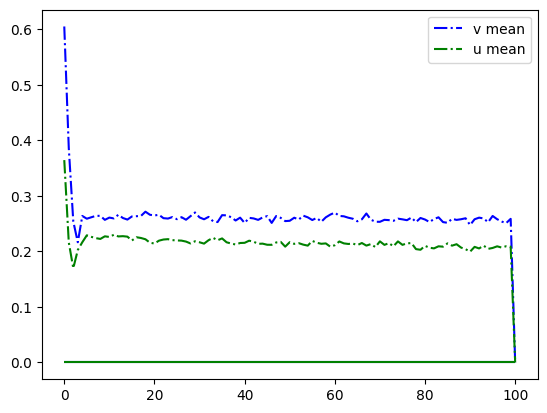

In [130]:
plt.plot(iterv.vmean_chain[:T_max+1], 'b-.', label = "v mean")
plt.hlines(0,0, T_max, 'b')

plt.plot(iterv.umean_chain[:T_max+1],'g-.', label = "u mean")
plt.hlines(0, 0, T_max,'g')

plt.legend()

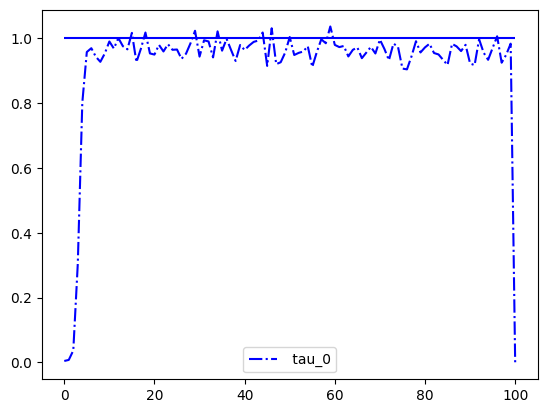

In [131]:
plt.plot(iterv.tau_chain[:T_max+1], 'b-.', label = " tau_0")
plt.hlines(x.tau_0,0, T_max, 'b')

plt.legend()


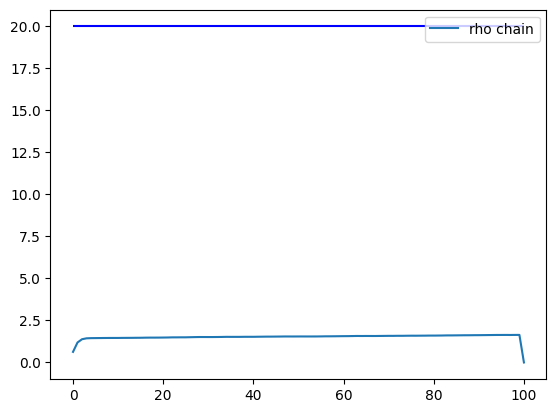

In [132]:
plt.plot(iterv.rho_chain, label = "rho chain")
plt.hlines(x.rho,0, T_max, 'b')
plt.legend()

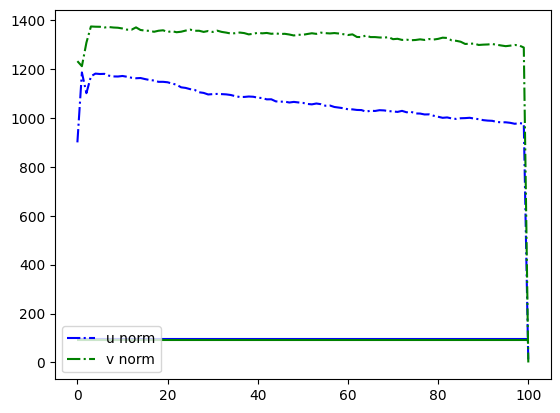

In [133]:
plt.plot(iterv.unorm_chain[:T_max+1], 'b-.', label = "u norm")
plt.hlines(x.u@x.u,0, T_max, 'b')

plt.plot(iterv.vnorm_chain[:T_max+1],'g-.', label = "v norm")
plt.hlines( x.v@x.v, 0, T_max,'g')
plt.legend()

## Coupled version

In [149]:
n_samples  = 50
I_all =  [100,200, 500]
regime = [1,2]
res = np.zeros((len(regime),n_samples, len(I_all)))

tau_0 = 2
rho = 10
distance = []
T_max = 1000

In [ ]:
for er,reg in enumerate(regime):
    for e,I in enumerate(I_all):
        for n in tqdm(range(n_samples)):
            x = Data()
            x.asymptotic_regimes(reg,I,tau_0, rho)
            iterv = iter_value(x, T_max+1)
            iterv2 = iter_value(x, T_max)
            for t in range(1):
                iterv.update_local_centering(x,t)
            distance = []
            for t in range(T_max):
                distance.append( np.sqrt(iterv.distance(iterv2)/(2+x.I+x.J)))
                if np.sqrt(iterv.distance(iterv2)/(2+x.I+x.J)) < 1e-3:
                    if iterv.coupled_update(iterv2, x,t, close = True)==-1:
                        break
                else:
                    iterv.coupled_update(iterv2, x,t,close = False)
            if t == T_max-1:
                print("bad")
            res[er,n,e] = t
            np.save("MF_def_nolc", res)

 46%|███████████████████▊                       | 23/50 [23:11<21:10, 47.05s/it]

In [181]:
res = np.load("MF_def_nolc.npy")
I_all=[100,200,500]

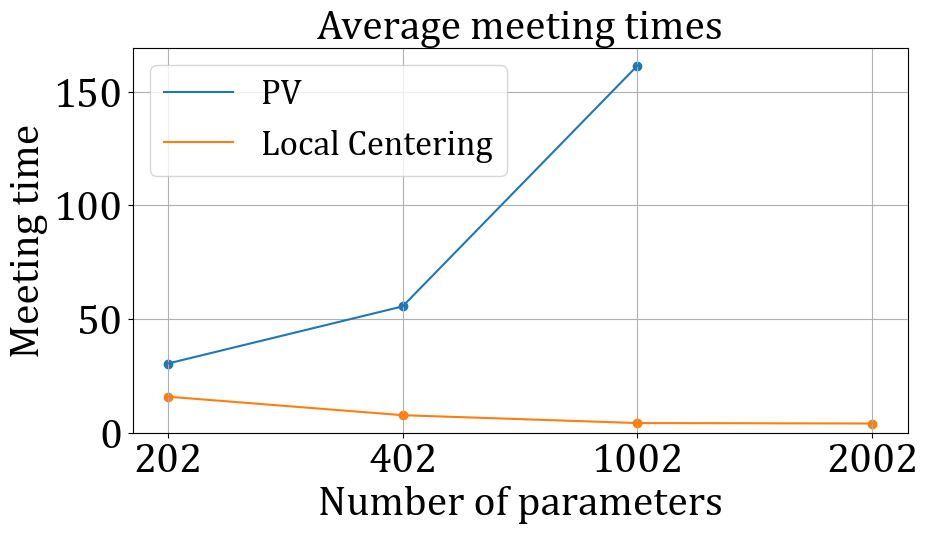

In [182]:
plt.figure(figsize=(10,5))
    
plt.rc('axes', labelsize=30)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=30)    # fontsize of the tick labels
plt.rc('ytick', labelsize=30)    # fontsize of the tick labels
plt.rc('font',family='Cambria Math')
matplotlib.rc('font',family='Cambria Math')
plt.plot(range(len(I_all)),np.mean(res[0], axis = 0), label= "PV")
plt.scatter(range(len(I_all)),np.mean(res[0], axis = 0))
plt.xticks(range(len(I_all)), 2+np.array(I_all)*2)

res = np.load("MF_def2.npy")
I_all=[100,200,500, 1000]
plt.plot(range(len(I_all)),np.mean(res[0], axis = 0), label ="Local Centering")
plt.scatter(range(len(I_all)),np.mean(res[0], axis = 0))
plt.xticks(range(len(I_all)), 2+np.array(I_all)*2)



plt.ylabel("Meeting time", fontsize= 30)
plt.xlabel("Number of parameters", fontsize= 30)
plt.legend(fontsize=25)
plt.title("Average meeting times",fontsize = 30)
plt.grid()
plt.ylim(0)
plt.savefig("reg1_MF_def"+'.png',  bbox_inches='tight')
plt.show()